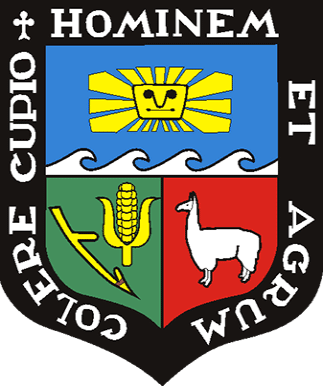
# **Universidad Nacional Agraria La Molina**
## **Facultad de Economía y Planificación**
## **Departamento Académico de Estadística e Informática**
## --------------------- **Trabajo Grupal** ---------------------
#### **Curso**: Lenguaje de Programación II
#### **Docente**: Denise Rosalyn Chalán Llajaruna
#### **Integrantes:**
- Guerrero Martínez, Jerson Julinho | 20241392
- Maguiña Tabory, Leonardo Fabio | 20241388
- Polo D'Arrigo, Salvatore Diego | 20241394
- Potosino Apaza, Andy Weber | 20241613
- Quispe López, Daiby Jaime | 20241396
- Salazar Vásquez, Ytzel Aleeza | 20240733

# **Análisis de ofertas de laptops en Mercado Libre Perú**

En Mercado Libre, la oferta de laptops es una práctica bastante frecuente que realizan muchos vendedores debido a la alta demanda de este artefacto. Muchas veces, en los títulos cuelgan detalles relevantes del aparato electrónico, tal como su marca, capacidad de almacenamiento, etc.
El análisis correspondiente agarrará 3 variables a estudiar de estos artefactos:
- Precio (en S/)
- Marca
- Almacenamiento (en GB)
 
Con técnicas de WebScraping, Request, regex y expresiones regulares, pandas y conversión de dataframes y la visualización de los datos podremos extraer información significativa para el estudio.  
Al final, todo el código se reorganizará en funciones distribuidas en clases creadas en POO.

#### **Request**

In [6]:
import requests
import time

def descargar_pagina_mercadolibre(url):
    """
    Función que se encarga de la petición HTTP a Mercado Libre.
    Acepta una URL específica como parámetro para soportar la paginación.
    """
    # El "Pase VIP" de Googlebot para evitar bloqueos
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)"
    }

    try:
        print(f"Descargando HTML desde -> {url}")
        respuesta = requests.get(url, headers=headers)
        
        # Verificamos si la conexión fue exitosa (Código 200)
        if respuesta.status_code == 200:
            print("¡Conexión exitosa! HTML descargado.")
            return respuesta.text
        else:
            print(f"Error. Código de estado: {respuesta.status_code}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"Error de red: {e}")
        return None

#### **Webscraping**

In [7]:
from bs4 import BeautifulSoup

def extraer_datos(html_bruto):
    """
    Toma el HTML descargado y extrae Título, Precio y Link de las laptops.
    """
    if not html_bruto: return []
    sopa = BeautifulSoup(html_bruto, 'html.parser')
    lista_laptops = []
    
    # Buscamos 'li' o 'div' que contengan la clase principal de los items
    elementos = sopa.find_all(['li', 'div'], class_=lambda c: c and 'ui-search-layout__item' in c)
   
    for item in elementos:
        etiqueta_a = item.find('a')
        link = etiqueta_a.get('href', 'Sin link') if etiqueta_a else 'Sin link'
        
        etiqueta_titulo = item.find(['h2', 'h3'])
        titulo = etiqueta_titulo.get_text(strip=True) if etiqueta_titulo else 'Sin título'
        
        etiqueta_precio = item.find('span', class_='andes-money-amount__fraction')
        precio = etiqueta_precio.get_text(strip=True).replace('.', '') if etiqueta_precio else '0'
       
        if len(titulo) > 10 and precio != '0':
            lista_laptops.append({
                "titulo_crudo": titulo,
                "precio": precio,
                "link": link
            })
        
    return lista_laptops

# Bloque de prueba rápido
if __name__ == "__main__":
    # Probamos con la página 2 para confirmar que funciona
    url_prueba = "https://listado.mercadolibre.com.pe/laptop_Desde_49"
    html_descargado = descargar_pagina_mercadolibre(url_prueba)
    
    if html_descargado:
        print(f"¡Listo! Se descargaron {len(html_descargado)} caracteres de código fuente.")##comit = "Función de descarga mejorada con soporte para paginación y manejo de errores robusto."

    # Bloque de prueba rápida 2:
    url_prueba_2 = "https://listado.mercadolibre.com.pe/laptop"
    html_descargado_2 = descargar_pagina_mercadolibre(url_prueba_2)
    
    if html_descargado_2:
        datos_extraidos_2 = extraer_datos(html_descargado_2)
        print(f"¡Éxito! Se encontraron {len(datos_extraidos_2)} laptops.")
        
        if datos_extraidos_2:
            print("Primer resultado de Prueba 2:", datos_extraidos_2[0])


##LAS LAPTOPS SE GUARDAN EN LA VARIABLE datos_extraidos_2

Descargando HTML desde -> https://listado.mercadolibre.com.pe/laptop_Desde_49
¡Conexión exitosa! HTML descargado.
¡Listo! Se descargaron 917450 caracteres de código fuente.
Descargando HTML desde -> https://listado.mercadolibre.com.pe/laptop
¡Conexión exitosa! HTML descargado.
¡Éxito! Se encontraron 48 laptops.
Primer resultado de Prueba 2: {'titulo_crudo': 'Apple 2026 Macbook Neo (de 13 Pulgadas, Chip A16 Pro De Apple Con Cpu De 6 Núcleos Y Gpu De 5 Núcleos, 8gb Memoria Unificada, 256\xa0gb) - Rosa Rubor - Distribuidor Autorizado', 'precio': '2899', 'link': 'https://www.mercadolibre.com.pe/apple-2026-macbook-neo-de-13-pulgadas-chip-a16-pro-de-apple-con-cpu-de-6-nucleos-y-gpu-de-5-nucleos-8gb-memoria-unificada-256gb-rosa-rubor-distribuidor-autorizado/p/MPE1066172675#polycard_client=search-desktop&be_origin=backend&search_layout=grid&position=1&type=product&tracking_id=48940d26-f39e-41cc-a842-1a0675c7b486&wid=MPE1082501326&sid=search'}


#### **Regex y expresiones regulares**

In [27]:
import re

MARCAS_CONOCIDAS = [
    "HP", "Lenovo", "Dell", "Asus", "Acer", "Apple", "MacBook",
    "Samsung", "Huawei", "MSI", "Toshiba", "Microsoft", "LG",
    "Gateway", "Compaq", "Vaio", "Sony"
]

SUB_MARCAS = {
    "victus": "HP", "omen": "HP", "pavilion": "HP", "probook": "HP", "elitebook": "HP",
    "ideapad": "Lenovo", "thinkpad": "Lenovo", "legion": "Lenovo", "loq": "Lenovo", "yoga": "Lenovo",
    "vivobook": "Asus", "zenbook": "Asus", "rog": "Asus", "tuf": "Asus",
    "inspiron": "Dell", "xps": "Dell", "latitude": "Dell", "vostro": "Dell",
    "predator": "Acer", "nitro": "Acer", "aspire": "Acer", "swift": "Acer",
    "galaxy book": "Samsung",
}

def extraer_marca(titulo):
    for marca in MARCAS_CONOCIDAS:
        patron = r"\b" + re.escape(marca) + r"\b"
        if re.search(patron, titulo, re.IGNORECASE):
            if marca.lower() == "macbook":
                return "Apple"
            return marca

    for sub_marca, marca_real in SUB_MARCAS.items():
        if re.search(r"\b" + re.escape(sub_marca) + r"\b", titulo, re.IGNORECASE):
            return marca_real

    return "Desconocida"

def _extraer_memoria(titulo):
    texto = titulo

    patron_storage = re.compile(r"\b(\d{1,4})\s*(GB|TB)?\s*(SSD|HDD|eMMC)\b", re.IGNORECASE)
    patron_storage_rev = re.compile(r"\b(SSD|HDD|eMMC)\s*(\d{1,4})\s*(GB|TB)?\b", re.IGNORECASE)

    almacenamiento = None
    tipo = "Desconocido"
    span_storage = None

    m_storage = patron_storage.search(texto)
    if m_storage:
        valor = int(m_storage.group(1))
        if m_storage.group(2) and m_storage.group(2).upper() == "TB":
            valor *= 1024
        almacenamiento = valor
        tipo = m_storage.group(3).upper()
        span_storage = m_storage.span()
    else:
        m_storage_rev = patron_storage_rev.search(texto)
        if m_storage_rev:
            valor = int(m_storage_rev.group(2))
            if m_storage_rev.group(3) and m_storage_rev.group(3).upper() == "TB":
                valor *= 1024
            almacenamiento = valor
            tipo = m_storage_rev.group(1).upper()
            span_storage = m_storage_rev.span()

    def se_solapa(span):
        return span_storage and not (span[1] <= span_storage[0] or span[0] >= span_storage[1])

    ram = None
    span_ram = None
    patron_ram_1 = re.compile(r"\b(\d{1,4})\s*(GB|TB)\s*(?:de\s*)?(?:Ram\b|Memoria)", re.IGNORECASE)
    patron_ram_2 = re.compile(r"\bRam\s*(\d{1,4})\s*(GB|TB)\b", re.IGNORECASE)
    patron_ram_3 = re.compile(r"\b(\d{1,3})\s*Ram\b", re.IGNORECASE)

    m_ram = patron_ram_1.search(texto)
    if m_ram and not se_solapa(m_ram.span()):
        valor = int(m_ram.group(1))
        if m_ram.group(2).upper() == "TB":
            valor *= 1024
        ram = valor
        span_ram = m_ram.span()
    else:
        m_ram2 = patron_ram_2.search(texto)
        if m_ram2 and not se_solapa(m_ram2.span()):
            valor = int(m_ram2.group(1))
            if m_ram2.group(2).upper() == "TB":
                valor *= 1024
            ram = valor
            span_ram = m_ram2.span()
        else:
            m_ram3 = patron_ram_3.search(texto)
            if m_ram3 and not se_solapa(m_ram3.span()):
                valor = int(m_ram3.group(1))
                if 2 <= valor <= 128:
                    ram = valor
                    span_ram = m_ram3.span()

    patron_generico = re.compile(r"\b(\d{1,4})\s*(GB|TB)\b", re.IGNORECASE)
    restantes = []
    for gm in patron_generico.finditer(texto):
        span = gm.span()
        if se_solapa(span):
            continue
        if span_ram and not (span[1] <= span_ram[0] or span[0] >= span_ram[1]):
            continue
        valor = int(gm.group(1))
        if gm.group(2).upper() == "TB":
            valor *= 1024
        restantes.append(valor)

    es_apple = bool(re.search(r"apple|macbook", texto, re.IGNORECASE))

    if ram is None and almacenamiento is None:
        if len(restantes) >= 2:
            ram, almacenamiento = restantes[0], restantes[1]
        elif len(restantes) == 1:
            if es_apple:
                almacenamiento = restantes[0]
                tipo = "SSD"
            else:
                ram = restantes[0]
    elif ram is None and restantes:
        ram = restantes[0]
    elif almacenamiento is None and restantes:
        almacenamiento = restantes[0]

    if es_apple and almacenamiento is not None and tipo == "Desconocido":
        tipo = "SSD"

    if ram is not None and almacenamiento is not None and ram > almacenamiento:
        ram, almacenamiento = almacenamiento, ram

    return ram, almacenamiento, tipo


def extraer_ram(titulo):
    ram, _, _ = _extraer_memoria(titulo)
    return ram


def extraer_almacenamiento(titulo):
    _, almacenamiento, _ = _extraer_memoria(titulo)
    return almacenamiento


def extraer_tipo_almacenamiento(titulo):
    _, _, tipo = _extraer_memoria(titulo)
    return tipo

def extraer_titulo_limpio(titulo):
    return re.sub(r"\s+", " ", titulo).strip()


def procesar_laptops(lista_laptops):
    lista_marca = []
    lista_almacenamiento = []
    lista_precio = []
    lista_link = []

    for laptop in lista_laptops:
        titulo_crudo = laptop.get("titulo_crudo", "")

        lista_marca.append(extraer_marca(titulo_crudo))
        
        almacenamiento = extraer_almacenamiento(titulo_crudo)
        lista_almacenamiento.append(1024 if almacenamiento is None else almacenamiento)

        precio_raw = laptop.get("precio", "0")
        try:
            lista_precio.append(int(precio_raw))
        except (ValueError, TypeError):
            lista_precio.append(None)

        lista_link.append(laptop.get("link", "Sin link"))

    return (
        lista_marca,
        lista_almacenamiento,
        lista_precio,
        lista_link,
    )


if __name__ == "__main__":
    from Scraper import descargar_pagina_mercadolibre, extraer_datos

    url_prueba = "https://listado.mercadolibre.com.pe/laptop"
    html_descargado = descargar_pagina_mercadolibre(url_prueba)

    if html_descargado:
        laptops = extraer_datos(html_descargado)

        if laptops:
            (lista_marca, lista_almacenamiento, lista_precio, lista_link) = procesar_laptops(laptops)

            print("Lista Marca:", lista_marca)
            print("Lista Almacenamiento:", lista_almacenamiento)
            print("Lista Precio:", lista_precio)


Descargando HTML desde -> https://listado.mercadolibre.com.pe/laptop
¡Conexión exitosa! HTML descargado.
Lista Marca: ['Apple', 'Apple', 'Apple', 'Lenovo', 'HP', 'Apple', 'Asus', 'Apple', 'HP', 'Lenovo', 'HP', 'Lenovo', 'Apple', 'Asus', 'HP', 'HP', 'Apple', 'Lenovo', 'Asus', 'Asus', 'Lenovo', 'Acer', 'HP', 'Apple', 'Apple', 'Lenovo', 'Apple', 'Asus', 'Lenovo', 'Apple', 'Lenovo', 'HP', 'Lenovo', 'Apple', 'HP', 'Asus', 'Apple', 'Asus', 'Asus', 'Apple', 'HP', 'Lenovo', 'Asus', 'Asus', 'Lenovo', 'Apple', 'Lenovo', 'Lenovo']
Lista Almacenamiento: [256, 256, 256, 1024, 1024, 512, 1024, 256, 512, 512, 1024, 512, 512, 512, 512, 1024, 512, 2048, 1024, 1024, 512, 1024, 1024, 256, 512, 1024, 512, 1024, 512, 256, 1024, 1024, 512, 512, 512, 1024, 256, 512, 1024, 1024, 512, 512, 512, 1024, 1024, 512, 512, 512]
Lista Precio: [2899, 2899, 2899, 7732, 4999, 4599, 6871, 4999, 2999, 4999, 5025, 4199, 4489, 6199, 3299, 3449, 5299, 11599, 5499, 6865, 3919, 12479, 3599, 2849, 7399, 7999, 5999, 11065, 3800, 

#### **Uso de Pandas y elaboración del DataFrame**

In [28]:
import pandas as pd

dicc = {"Marca": lista_marca, "Almacenamiento": lista_almacenamiento, "Lista Precio": lista_precio}

DataFrameDatos = pd.DataFrame(dicc)
DataFrameDatos

,Marca,Almacenamiento,Lista Precio
0,Apple,256,2899
1,Apple,256,2899
2,Apple,256,2899
3,Lenovo,1024,7732
4,HP,1024,4999
5,Apple,512,4599
6,Asus,1024,6871
7,Apple,256,4999
8,HP,512,2999
9,Lenovo,512,4999


#### **Visualización de los datos**

#### **Organización del código en POO**